# Quanto vale um apartamento em São Paulo?
## Random Forest, XGBoost e LightGBM — continuação do CP04

**Data Science & Statistical Computing — Checkpoint 5 — FIAP 2026**

**Grupo:** Enzo Augusto (RM562249) · Rafaell Santiago (RM563486) · Gustavo Neres (RM561785) · Sebastian Iriarte (RM563619)

---

## Resumo do projeto

**Problema.** Estimar o preço de venda anunciado de apartamentos em São Paulo a partir das características do imóvel (área, quartos, banheiros, suítes, vagas, condomínio, itens do prédio e localização). É um problema de regressão e continua o que fizemos no CP04, agora com modelos de árvore.

**Base.** *São Paulo Real Estate — Sale / Rent — April 2019* (Kaggle). 6.412 anúncios de venda, 6.240 depois do tratamento.

**Protocolo.** Treino 80% e teste 20%. Dentro do treino, validação cruzada com 5 folds, a mesma para os três modelos e para todas as buscas. Métrica principal: RMSE em reais. O teste só foi usado no final.

**Resultado.**

| Etapa | Modelo | RMSE | MAE | R² |
|---|---|---|---|---|
| Validação cruzada | LightGBM (Grid Search) | R\$ 223,6 mil | R\$ 96,6 mil | 0,91 |
| Teste final | LightGBM (Grid Search) | R\$ 191,5 mil | R\$ 87,9 mil | 0,94 |

**Onde está cada parte**

1. Definição do problema e da base
2. Data wrangling e análise exploratória
3. Escolha de variáveis e desenho experimental
4. Modelos de referência (Random Forest, XGBoost e LightGBM)
5. Tuning com Grid Search e Optuna
6. Escolha do modelo, overfitting e underfitting
7. Teste final, teste de consistência, GitHub, Streamlit e síntese da apresentação

---

---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>

<br>

---

<br>

## **Identificação dos alunos**

**Grupo:** Enzo Augusto (RM562249) · Rafaell Santiago (RM563486) · Gustavo Neres (RM561785) · Sebastian Iriarte (RM563619)

<br>

---

<br>

# **CheckPoint05**

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

## **Instruções**

- Leia cada enunciado com atenção.
- Observe a pontuação indicada em cada questão. A atividade vale **10 pontos** no total.
- O grupo deve escolher **um único problema** que possa ser tratado como classificação ou regressão e utilizar a mesma base em toda a atividade.
- A base pode ser pública, institucional autorizada ou coletada pelo grupo. A fonte, a licença ou a forma de obtenção devem ser documentadas.
- O problema deve produzir uma representação tabular de atributos e variável-alvo. Não utilize dados pessoais ou sensíveis sem autorização e justificativa acadêmica adequada.
- Sempre que necessário, registre o raciocínio antes da implementação em Python.
- Quando o item pedir interpretação, responda com base nos resultados obtidos, não apenas com definições genéricas.
- Responda os exercícios nos espaços indicados. Caso seja necessário, adicione células para complementar a resposta.
- Indique de forma organizada a solução dos exercícios.
- Preocupe-se em fazer um código Python limpo, documentado e reprodutível. Esse aspecto será avaliado ao longo de toda a atividade.
- O conjunto de **teste deve permanecer isolado** durante seleção de variáveis, comparação de modelos e tuning. Ele só poderá ser utilizado no Exercício 7.
- O envio da atividade deve incluir o notebook `.ipynb`, o link do repositório GitHub e o link da aplicação Streamlit.
- Cada grupo deverá realizar uma **apresentação oral da solução, com duração máxima de 10 minutos**, sintetizando o problema, as principais decisões metodológicas, a comparação entre os modelos, o modelo final e a demonstração da aplicação.
- Execute o notebook do início ao fim antes do envio. Ele não deve conter erros durante a execução.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Entregáveis obrigatórios:</strong> notebook final, repositório GitHub reproduzível, aplicação Streamlit funcional e **apresentação oral da solução com duração máxima de 10 minutos**. O repositório deve conter, no mínimo, README com instruções de execução, arquivo de dependências, código da aplicação e os arquivos necessários para reproduzir o treinamento ou carregar o modelo final.
</div>

In [2]:
# imports e configuração visual do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager

fontes_preferidas = [
    "Latin Modern Roman",
    "CMU Serif",
    "Georgia",
    "DejaVu Serif",
]

fonte_serif = "DejaVu Serif"
for fonte in fontes_preferidas:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Fonte serifada selecionada para os gráficos: {fonte_serif}")

Fonte serifada selecionada para os gráficos: Latin Modern Roman


In [3]:
# bibliotecas usadas no projeto
import os
import sys
import json
import subprocess
import warnings
from time import perf_counter

# no Colab, xgboost/lightgbm/optuna podem precisar ser instalados
for pacote in ["xgboost", "lightgbm", "optuna"]:
    try:
        __import__(pacote)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

import joblib
from IPython.display import display
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (train_test_split, KFold, cross_validate, cross_val_score,
                                     cross_val_predict, GridSearchCV, learning_curve)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<br>

---

<br>

## **Notação utilizada na atividade**

Considere a base de dados como

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n},
$$

em que $\mathbf{x}_i$ representa as variáveis preditoras da observação $i$ e $y_i$ representa a variável-alvo. Ao organizar os dados, utilize a notação

$$
\mathbf{X} \quad \text{para a matriz de atributos},
\qquad
\mathbf{y} \quad \text{para o vetor da variável-alvo}.
$$

A separação deve produzir

$$
\mathcal{D}_{\mathrm{treino}}
\quad \text{e} \quad
\mathcal{D}_{\mathrm{teste}},
$$

sendo $\mathcal{D}_{\mathrm{teste}}$ mantido fora de todo o processo de seleção e tuning. Os três modelos serão indicados por

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

As previsões serão representadas por $\hat{\mathbf{y}}$. Para hiperparâmetros, utilize $\boldsymbol{\theta}$ e registre os melhores valores encontrados por cada estratégia de busca.

<br>

---

<br>

## **Exercícios propostos**

A atividade foi organizada como um fluxo completo de desenvolvimento de um projeto de machine learning. Os sete exercícios devem ser respondidos em sequência, pois as decisões tomadas nas etapas iniciais serão utilizadas nas etapas seguintes.

<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.

**Resposta do aluno — Exercício 1**

Descreva o problema, a base, a variável-alvo e o critério de sucesso.

Este trabalho continua o CP04. Lá usamos regressão linear e polinomial para estimar o preço de apartamentos em São Paulo; aqui usamos a mesma base e o mesmo problema, agora com Random Forest, XGBoost e LightGBM.

**Contexto e problema.** O preço de apartamentos em São Paulo varia muito, mesmo entre imóveis parecidos, e é difícil saber se um valor anunciado está dentro do mercado. Queremos estimar o preço de venda de um apartamento a partir das suas características: área, quartos, banheiros, suítes, vagas, condomínio, itens do prédio e localização. Temos milhares de anúncios com essas informações e o preço, então dá para treinar um modelo supervisionado. No CP04 vimos que a relação entre as variáveis e o preço não é linear, e modelos de árvore lidam melhor com isso.

**Variável-alvo.** $y$ é o preço de venda anunciado, em reais. Como é um valor contínuo, o problema é de regressão. A previsão $\hat{y}$ é o preço esperado para um apartamento com aquelas características. Como a base é de anúncios, $\hat{y}$ representa o preço pedido, e não o valor pelo qual o imóvel foi vendido.

**Base de dados.** *São Paulo Real Estate — Sale / Rent — April 2019*, do Kaggle (https://www.kaggle.com/datasets/argonalyst/sao-paulo-real-estate-sale-rent-april-2019). São anúncios de sites de classificados coletados em abril de 2019. Cada linha é um anúncio. Lemos o CSV por uma cópia pública (a mesma usada no CP04), para o notebook rodar sem download manual.

In [4]:
url = "https://raw.githubusercontent.com/mathdeoliveira/files/master/sao-paulo-properties-april-2019.csv"
imoveis = pd.read_csv(url)

print("Linhas e colunas da base original:", imoveis.shape)
print()
print(imoveis["Negotiation Type"].value_counts())
imoveis.head()

Linhas e colunas da base original: (13640, 16)

Negotiation Type
rent    7228
sale    6412
Name: count, dtype: int64


,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,District,Negotiation Type,Property Type,Latitude,Longitude
0,930,220,47,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.543138,-46.479486
1,1000,148,45,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.550239,-46.480718
2,1000,100,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.542818,-46.485665
3,1000,200,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.547171,-46.483014
4,1300,410,55,2,2,1,1,1,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.525025,-46.482436


Dicionário de dados:

| Coluna | Nome no projeto | Tipo | Unidade | Descrição |
|---|---|---|---|---|
| Price | preco | contínua | R$ | Preço anunciado (alvo) |
| Condo | condominio | contínua | R$/mês | Condomínio mensal (0 quando não informado) |
| Size | area_m2 | contínua | m² | Área privativa |
| Rooms | quartos | discreta | unidades | Quartos |
| Toilets | banheiros | discreta | unidades | Banheiros |
| Suites | suites | discreta | unidades | Suítes |
| Parking | vagas | discreta | unidades | Vagas de garagem |
| Elevator | elevador | 0/1 | — | Prédio com elevador |
| Furnished | mobiliado | 0/1 | — | Imóvel mobiliado |
| Swimming Pool | piscina | 0/1 | — | Condomínio com piscina |
| New | novo | 0/1 | — | Imóvel novo |
| District | distrito | categórica | — | Distrito de São Paulo |
| Negotiation Type | — | categórica | — | Venda (sale) ou aluguel (rent) |
| Property Type | — | categórica | — | Tipo de imóvel |
| Latitude, Longitude | latitude, longitude | contínuas | graus | Localização do anúncio |

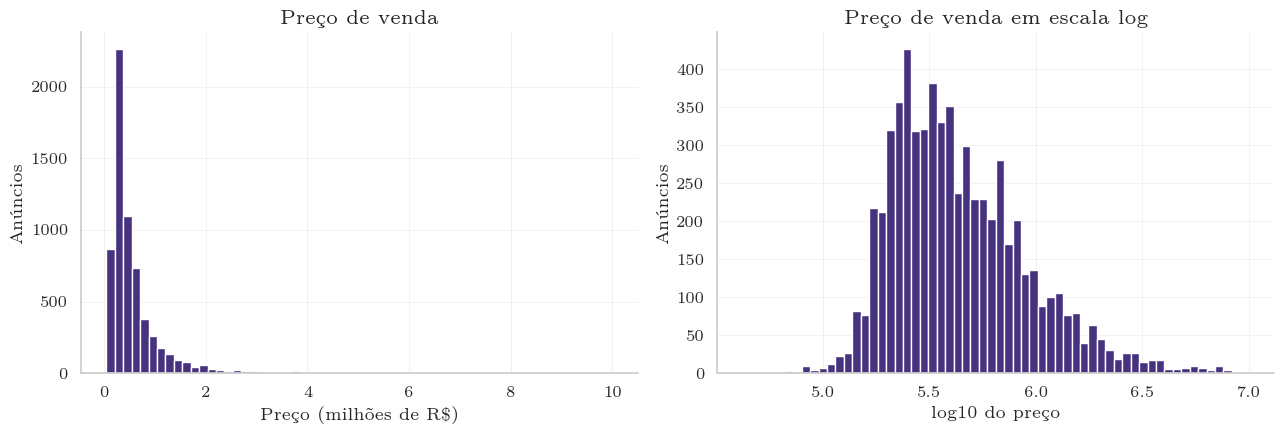

count        6412.0
mean       608624.0
std        740452.0
min         42000.0
25%        250000.0
50%        380000.0
75%        679000.0
max      10000000.0
Name: Price, dtype: float64
Assimetria do preço: 5.1
Assimetria do log do preço: 0.84


In [5]:
# distribuição do preço de venda
venda_bruta = imoveis[imoveis["Negotiation Type"] == "sale"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(venda_bruta["Price"] / 1e6, bins=60)
ax[0].set_title("Preço de venda")
ax[0].set_xlabel("Preço (milhões de R$)")
ax[0].set_ylabel("Anúncios")
ax[1].hist(np.log10(venda_bruta["Price"]), bins=60)
ax[1].set_title("Preço de venda em escala log")
ax[1].set_xlabel("log10 do preço")
ax[1].set_ylabel("Anúncios")
plt.tight_layout()
plt.show()

print(venda_bruta["Price"].describe().round(0))
print("Assimetria do preço:", round(venda_bruta["Price"].skew(), 2))
print("Assimetria do log do preço:", round(np.log(venda_bruta["Price"]).skew(), 2))

A maioria dos anúncios fica abaixo de R$ 1 milhão (mediana de R$ 380 mil), mas alguns chegam a R$ 10 milhões, o que puxa a média para R$ 609 mil. A assimetria é de 5,1. Em escala log a distribuição fica bem mais equilibrada (assimetria de 0,84), por isso vamos treinar os modelos com o log do preço. Isso é comum em preço de imóvel: o House Prices usado nas aulas tem o mesmo comportamento.

**Critério de sucesso.** A métrica principal é o RMSE em reais. Ela pesa mais os erros grandes, e em preço de imóvel errar muito em um apartamento é pior do que errar pouco em vários. Usamos também o MAE (erro médio em reais, mais fácil de explicar) e o R² (quanto da variação do preço o modelo explica). Todos os modelos, buscas e a escolha final usam o RMSE.

<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>

**Resposta do aluno — Exercício 2**

Explique as decisões de data wrangling e interprete os principais achados da análise exploratória.

Como no CP04, ficamos só com os anúncios de venda. Desta vez olhamos a base com mais cuidado antes de tratar, porque no CP04 deixamos passar alguns problemas.

In [6]:
venda = imoveis[imoveis["Negotiation Type"] == "sale"].copy()
venda = venda.rename(columns={
    "Price": "preco", "Condo": "condominio", "Size": "area_m2", "Rooms": "quartos",
    "Toilets": "banheiros", "Suites": "suites", "Parking": "vagas", "Elevator": "elevador",
    "Furnished": "mobiliado", "Swimming Pool": "piscina", "New": "novo", "District": "distrito",
    "Latitude": "latitude", "Longitude": "longitude",
})
venda["distrito"] = venda["distrito"].str.replace("/São Paulo", "", regex=False)
venda = venda.drop(columns=["Negotiation Type", "Property Type"])  # só venda e só apartamento

print("Anúncios de venda:", venda.shape)
print("Valores ausentes:", venda.isna().sum().sum())
print("Linhas duplicadas:", venda.duplicated().sum())
print("Condomínio igual a 0:", (venda["condominio"] == 0).sum())
print("Latitude ou longitude igual a 0:", ((venda["latitude"] == 0) | (venda["longitude"] == 0)).sum())
print("Suítes maior que quartos:", (venda["suites"] > venda["quartos"]).sum())
print("Preço ou área menor ou igual a 0:", ((venda["preco"] <= 0) | (venda["area_m2"] <= 0)).sum())
print(venda.dtypes)

Anúncios de venda: (6412, 14)
Valores ausentes: 0
Linhas duplicadas: 110
Condomínio igual a 0: 1337
Latitude ou longitude igual a 0: 398
Suítes maior que quartos: 2
Preço ou área menor ou igual a 0: 0
preco           int64
condominio      int64
area_m2         int64
quartos         int64
banheiros       int64
suites          int64
vagas           int64
elevador        int64
mobiliado       int64
piscina         int64
novo            int64
distrito          str
latitude      float64
longitude     float64
dtype: object


In [7]:
# coordenadas preenchidas, mas fora da cidade de São Paulo
dentro_sp = venda["latitude"].between(-24, -23.3) & venda["longitude"].between(-47, -46.3)
com_coord = (venda["latitude"] != 0) & (venda["longitude"] != 0)
print("Anúncios com coordenada fora da cidade:", (com_coord & ~dentro_sp).sum())
print(venda[com_coord & ~dentro_sp]["distrito"].value_counts().head())
print()
print("Coordenada mediana do distrito Medeiros:")
print(venda[(venda["distrito"] == "Medeiros") & com_coord][["latitude", "longitude"]].median())

Anúncios com coordenada fora da cidade: 73
distrito
Medeiros        32
Barra Funda      4
Aricanduva       4
Bela Vista       4
Cidade Dutra     3
Name: count, dtype: int64

Coordenada mediana do distrito Medeiros:
latitude    -23.183597
longitude   -46.985039
dtype: float64


A base não tem nenhum valor vazio, mas tem problemas escondidos:

- 110 anúncios repetidos, iguais em todas as colunas, inclusive nas coordenadas.
- 1.337 anúncios com condomínio igual a 0. Apartamento não tem condomínio zero, então isso quer dizer que a informação não foi preenchida.
- 398 anúncios com latitude ou longitude igual a 0, e 73 com coordenadas fora da cidade.
- 32 desses 73 são do "distrito" Medeiros, cuja coordenada mediana (-23,18; -46,99) fica na região de Jundiaí. Medeiros não é distrito de São Paulo.
- 2 anúncios com mais suítes do que quartos.

No CP04 só tínhamos tratado as duplicatas e o condomínio zerado.

In [8]:
linhas_antes = len(venda)

# 1) anúncios repetidos (todas as colunas iguais, inclusive coordenadas)
venda = venda.drop_duplicates()
print("Duplicatas removidas:", linhas_antes - len(venda))

# 2) Medeiros não é distrito de São Paulo (coordenadas na região de Jundiaí)
antes = len(venda)
venda = venda[venda["distrito"] != "Medeiros"]
print("Anúncios de Medeiros removidos:", antes - len(venda))

# 3) mais suítes do que quartos é erro de cadastro
antes = len(venda)
venda = venda[venda["suites"] <= venda["quartos"]]
print("Anúncios com suítes > quartos removidos:", antes - len(venda))

Duplicatas removidas: 110
Anúncios de Medeiros removidos: 49
Anúncios com suítes > quartos removidos: 2


In [9]:
# 4) valores "zerados" que na verdade estão faltando viram NaN
# (a mesma regra é aplicada no app do Streamlit)
def limpar_imovel(df):
    df = df.copy()
    df["condominio"] = df["condominio"].replace(0, np.nan)
    fora_sp = ~(df["latitude"].between(-24, -23.3) & df["longitude"].between(-47, -46.3))
    df.loc[fora_sp, ["latitude", "longitude"]] = np.nan
    return df

venda = limpar_imovel(venda)
print("Condomínio sem informação:", venda["condominio"].isna().sum())
print("Coordenadas sem informação:", venda["latitude"].isna().sum())

Condomínio sem informação: 1280
Coordenadas sem informação: 428


In [10]:
# 5) preços muito fora do padrão do próprio distrito (preço por m²)
preco_m2 = venda["preco"] / venda["area_m2"]
razao = preco_m2 / preco_m2.groupby(venda["distrito"]).transform("median")
suspeitos = venda[(razao < 1/3) | (razao > 3)]

tabela = suspeitos[["preco", "area_m2", "quartos", "vagas", "distrito"]].copy()
tabela["preco_m2"] = preco_m2[suspeitos.index].round(0)
tabela["vezes_a_mediana"] = razao[suspeitos.index].round(2)
tabela.sort_values("vezes_a_mediana")

,preco,area_m2,quartos,vagas,distrito,preco_m2,vezes_a_mediana
8487,42000,48,1,1,República,875.0,0.13
11377,68000,90,3,2,Aricanduva,756.0,0.16
13141,415000,335,1,1,Tatuapé,1239.0,0.17
13261,136600,98,2,1,Vila Jacuí,1394.0,0.30
6421,45000,40,2,1,Lajeado,1125.0,0.32
7975,100000,55,2,1,Pirituba,1818.0,0.33
11754,98815,51,2,1,Socorro,1938.0,0.33
7519,98815,51,2,1,Socorro,1938.0,0.33
5025,915000,30,3,2,Mooca,30500.0,4.18
11578,3050003,66,3,1,Vila Prudente,46212.0,7.86


Esses 10 anúncios têm preço por m² menor que um terço ou maior que três vezes o normal do distrito. Olhando um por um, parecem erros de digitação: 48 m² na República por R$ 42 mil, 335 m² com 1 quarto no Tatuapé por R$ 415 mil, 30 m² com 3 quartos na Mooca e 66 m² em Vila Prudente por R$ 3.050.003. Os dois de Socorro são o mesmo anúncio repetido. Como são poucos e não representam o mercado, removemos.

In [11]:
venda = venda.drop(index=suspeitos.index)
venda = venda.drop_duplicates().reset_index(drop=True)  # confere de novo depois da limpeza

print("Base original de venda:", venda_bruta.shape)
print("Base tratada:", venda.shape)
print("Duplicatas:", venda.duplicated().sum())
print("Ausentes por coluna:")
print(venda.isna().sum()[venda.isna().sum() > 0])

Base original de venda: (6412, 16)
Base tratada: (6240, 14)
Duplicatas: 0
Ausentes por coluna:
condominio    1275
latitude       423
longitude      423
dtype: int64


Os imóveis caros, que chegam a R$ 10 milhões, ficaram na base: são coerentes com área, vagas e bairro. O preço por m² foi usado só para achar os erros acima; ele é calculado a partir do preço, então não entra no modelo.

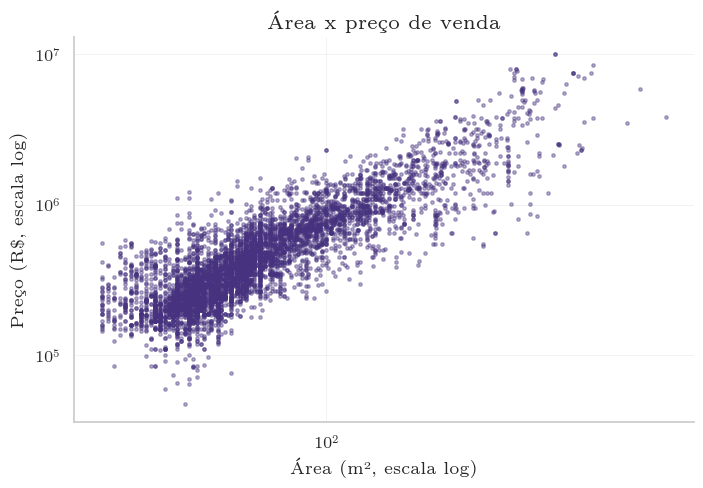

In [12]:
# gráfico: área x preço
plt.figure(figsize=(8, 5))
plt.scatter(venda["area_m2"], venda["preco"], s=6, alpha=0.4)
plt.xscale("log")
plt.yscale("log")
plt.title("Área x preço de venda")
plt.xlabel("Área (m², escala log)")
plt.ylabel("Preço (R$, escala log)")
plt.show()

Quanto maior a área, maior o preço, e a relação é forte (correlação de 0,84). Mas para uma mesma área o preço ainda varia muito, e boa parte dessa diferença vem da localização.

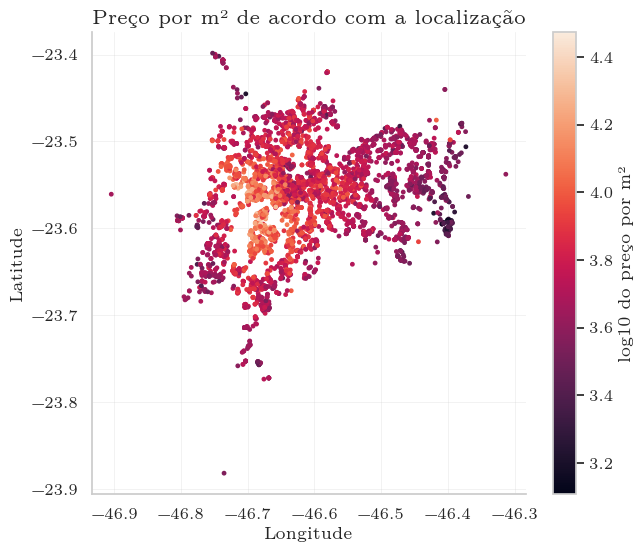

In [13]:
# gráfico: preço por m² no mapa
geo = venda.dropna(subset=["latitude", "longitude"])
plt.figure(figsize=(7, 6))
pontos = plt.scatter(geo["longitude"], geo["latitude"], c=np.log10(geo["preco"] / geo["area_m2"]), s=6)
plt.colorbar(pontos, label="log10 do preço por m²")
plt.title("Preço por m² de acordo com a localização")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

O preço por m² é mais alto na região sudoeste do centro e cai em direção às bordas da cidade, principalmente na zona leste. Como essa relação não é uma reta, latitude e longitude funcionam melhor em modelos de árvore do que na regressão linear do CP04, onde não usamos essas colunas.

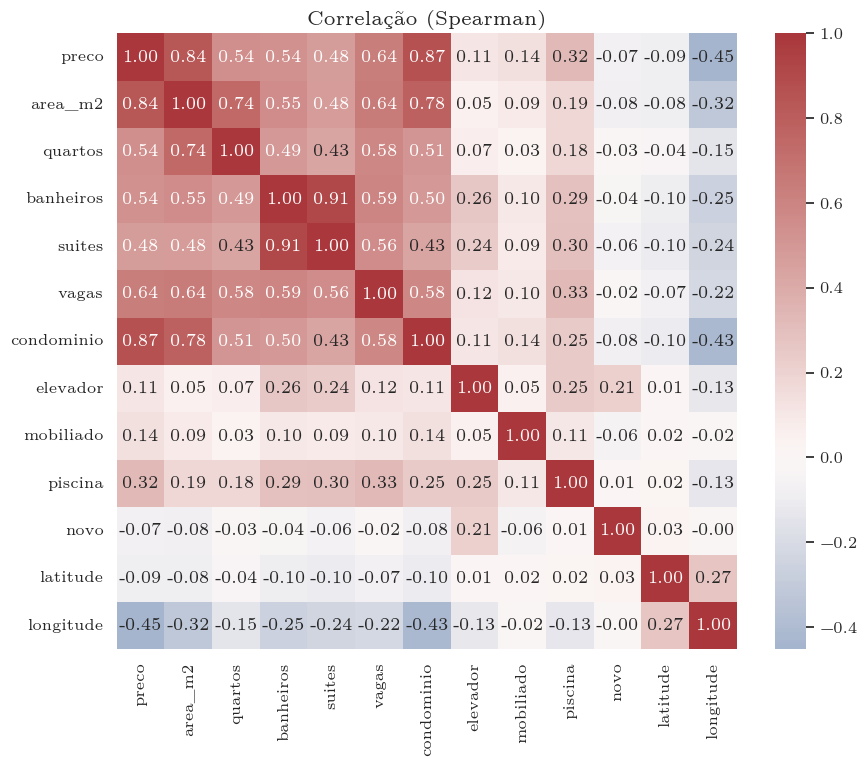

In [14]:
# gráfico: correlação entre as variáveis numéricas
numericas = ["preco", "area_m2", "quartos", "banheiros", "suites", "vagas", "condominio",
             "elevador", "mobiliado", "piscina", "novo", "latitude", "longitude"]
plt.figure(figsize=(10, 8))
sns.heatmap(venda[numericas].corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlação (Spearman)")
plt.show()

O preço tem correlação alta com o condomínio (0,87) e com a área (0,84), e média com vagas, quartos e banheiros. Essas variáveis também são muito correlacionadas entre si (banheiros e suítes, por exemplo, 0,91). No CP04 isso deixou os coeficientes instáveis; nos modelos de árvore não é um problema, porque eles não usam coeficientes.

Algumas etapas ficam para dentro do pipeline, porque precisam ser calculadas só com os dados de treino: preencher condomínio e coordenadas que faltam com a mediana e transformar o distrito em colunas 0/1.

<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>

**Resposta do aluno — Exercício 3**

Justifique as variáveis escolhidas, o particionamento dos dados, a validação cruzada e as métricas.

$X$ tem todas as características do imóvel e $y$ é o preço. Tiramos do modelo o preço por m² (vazamento, porque é calculado com o preço) e as colunas de tipo de negociação e de imóvel, que viraram constantes. O condomínio fica: ele não é calculado a partir do preço e aparece no anúncio, então estaria disponível na hora de prever.

No CP04 as variáveis parecidas entre si (área, quartos, banheiros) deixaram os coeficientes instáveis. Modelos de árvore não têm coeficientes, então podemos manter todas.

Separamos 80% para treino e 20% para teste, com `random_state=42`. Dentro do treino usamos validação cruzada com 5 folds; o mesmo `KFold` é usado em todos os modelos e buscas, então todos são avaliados nas mesmas partes da base. O teste só é usado no Exercício 7.

Métrica principal: RMSE. Auxiliares: MAE e R². O scikit-learn devolve o erro com sinal negativo (`neg_root_mean_squared_error`), por isso trocamos o sinal nas tabelas.

In [15]:
colunas_numericas = ["area_m2", "quartos", "banheiros", "suites", "vagas", "condominio",
                     "elevador", "mobiliado", "piscina", "novo", "latitude", "longitude"]
colunas_x = colunas_numericas + ["distrito"]

X = venda[colunas_x]
y = venda["preco"]

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=SEED)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)

Treino: (4992, 13) | Teste: (1248, 13)


O pipeline tem três partes. As colunas numéricas com valor faltando recebem a mediana do treino. O distrito vira colunas 0/1; distritos com menos de 40 anúncios no treino são juntados em um grupo só, porque sozinhos têm pouca informação (a latitude e a longitude continuam mostrando onde o imóvel fica). Por último, o modelo aprende o log do preço e a previsão volta para reais: como vimos no Exercício 1, o preço é muito assimétrico, e sem o log os poucos imóveis de luxo pesariam demais no treino.

In [16]:
def montar_pipeline(modelo):
    preparo = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=40, sparse_output=False), ["distrito"]),
    ])
    pipe = Pipeline([("preparo", preparo), ("modelo", modelo)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log, inverse_func=np.exp)


def avaliar(nome, modelo):
    t0 = perf_counter()
    res = cross_validate(montar_pipeline(modelo), X_treino, y_treino, cv=cv, return_train_score=True,
                         scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"])
    return {
        "Modelo": nome,
        "RMSE_treino": -res["train_neg_root_mean_squared_error"].mean(),
        "RMSE_CV": -res["test_neg_root_mean_squared_error"].mean(),
        "RMSE_CV_dp": res["test_neg_root_mean_squared_error"].std(),
        "MAE_CV": -res["test_neg_mean_absolute_error"].mean(),
        "R2_CV": res["test_r2"].mean(),
        "Tempo_s": perf_counter() - t0,
    }

<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.

**Resposta do aluno — Exercício 4**

Interprete o comportamento inicial dos três modelos e registre possíveis sinais de underfitting ou overfitting.

Os três modelos de referência usam hiperparâmetros parecidos com os das aulas, sem nenhum ajuste ainda.

In [17]:
rf_base = RandomForestRegressor(n_estimators=200, max_features=0.6, min_samples_leaf=2, random_state=SEED, n_jobs=-1)
xgb_base = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.85,
                        colsample_bytree=0.85, random_state=SEED, n_jobs=-1)
lgbm_base = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, min_child_samples=20,
                          subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
                          random_state=SEED, n_jobs=-1, verbose=-1)

baselines = pd.DataFrame([
    avaliar("Random Forest", rf_base),
    avaliar("XGBoost", xgb_base),
    avaliar("LightGBM", lgbm_base),
])
baselines.round(3)

,Modelo,RMSE_treino,RMSE_CV,RMSE_CV_dp,MAE_CV,R2_CV,Tempo_s
0,Random Forest,132543.883,248273.052,32248.092,105205.778,0.887,14.890
1,XGBoost,101998.391,233164.797,24843.347,98503.678,0.900,2.962
2,LightGBM,106277.657,224897.622,22037.790,96960.325,0.908,4.020


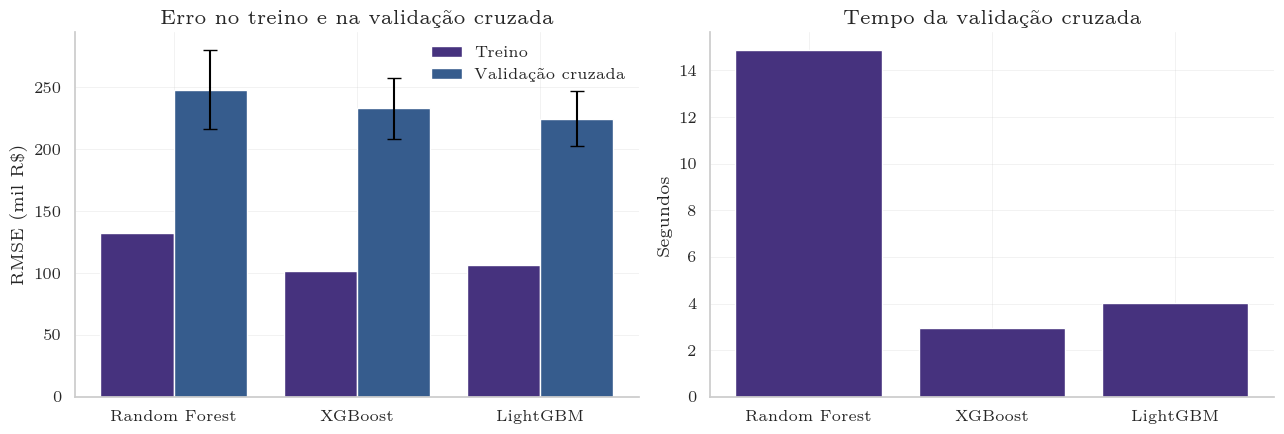

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
pos = np.arange(3)
ax[0].bar(pos - 0.2, baselines["RMSE_treino"] / 1000, 0.4, label="Treino")
ax[0].bar(pos + 0.2, baselines["RMSE_CV"] / 1000, 0.4, yerr=baselines["RMSE_CV_dp"] / 1000, capsize=5, label="Validação cruzada")
ax[0].set_xticks(pos, baselines["Modelo"])
ax[0].set_ylabel("RMSE (mil R$)")
ax[0].set_title("Erro no treino e na validação cruzada")
ax[0].legend()
ax[1].bar(baselines["Modelo"], baselines["Tempo_s"])
ax[1].set_ylabel("Segundos")
ax[1].set_title("Tempo da validação cruzada")
plt.tight_layout()
plt.show()

O LightGBM teve o menor erro de validação (RMSE de R$ 224,9 mil), seguido do XGBoost (R$ 233,2 mil) e do Random Forest (R$ 248,3 mil). A diferença entre LightGBM e XGBoost é menor que o desvio entre os folds (cerca de R$ 22 mil), então nessa etapa eles estão praticamente empatados. O Random Forest ficou atrás e foi o mais lento.

Nos três modelos o erro no treino é mais ou menos metade do erro na validação. Isso mostra que eles se ajustam bem ao treino e que existe algum overfitting, o que é comum em modelos de árvore. Não há underfitting: o R² de validação ficou perto de 0,9 nos três.

<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>

**Resposta do aluno — Exercício 5**

Explique os espaços de busca, os resultados obtidos e a comparação entre Grid Search e Optuna.

**Grid Search.** Em cada modelo testamos um valor menor e um maior para o número de árvores e para os parâmetros que controlam a complexidade; no XGBoost e no LightGBM, também a taxa de aprendizado. As grades são pequenas porque cada combinação é treinada 5 vezes.

In [19]:
grades = {
    "Random Forest": (rf_base, {
        "regressor__modelo__n_estimators": [100, 200],
        "regressor__modelo__max_depth": [None, 16],
        "regressor__modelo__min_samples_leaf": [1, 3],
        "regressor__modelo__max_features": [0.4, 0.8],
    }),
    "XGBoost": (xgb_base, {
        "regressor__modelo__n_estimators": [400, 900],
        "regressor__modelo__learning_rate": [0.03, 0.08],
        "regressor__modelo__max_depth": [4, 7],
        "regressor__modelo__min_child_weight": [1, 5],
    }),
    "LightGBM": (lgbm_base, {
        "regressor__modelo__n_estimators": [400, 900],
        "regressor__modelo__learning_rate": [0.03, 0.08],
        "regressor__modelo__num_leaves": [15, 31, 63],
        "regressor__modelo__min_child_samples": [10, 30],
    }),
}

buscas_grid = {}
linhas = []
for nome, (modelo, grade) in grades.items():
    busca = GridSearchCV(montar_pipeline(modelo), grade, cv=cv, scoring="neg_root_mean_squared_error",
                         return_train_score=True, refit=False)
    t0 = perf_counter()
    busca.fit(X_treino, y_treino)
    tempo = perf_counter() - t0
    buscas_grid[nome] = busca
    melhores = {k.replace("regressor__modelo__", ""): v for k, v in busca.best_params_.items()}
    print(nome, "- melhores parâmetros:", melhores)
    linhas.append({"Modelo": nome, "Combinações": len(busca.cv_results_["params"]),
                   "RMSE_CV": -busca.best_score_,
                   "RMSE_CV_dp": busca.cv_results_["std_test_score"][busca.best_index_],
                   "Tempo_s": tempo})

resultado_grid = pd.DataFrame(linhas)
resultado_grid.round(2)

Random Forest - melhores parâmetros: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'n_estimators': 200}


XGBoost - melhores parâmetros: {'learning_rate': 0.03, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 400}


LightGBM - melhores parâmetros: {'learning_rate': 0.08, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 31}


,Modelo,Combinações,RMSE_CV,RMSE_CV_dp,Tempo_s
0,Random Forest,16,241666.93,28910.49,185.13
1,XGBoost,16,231022.26,21472.14,75.87
2,LightGBM,24,223550.78,23047.04,137.81


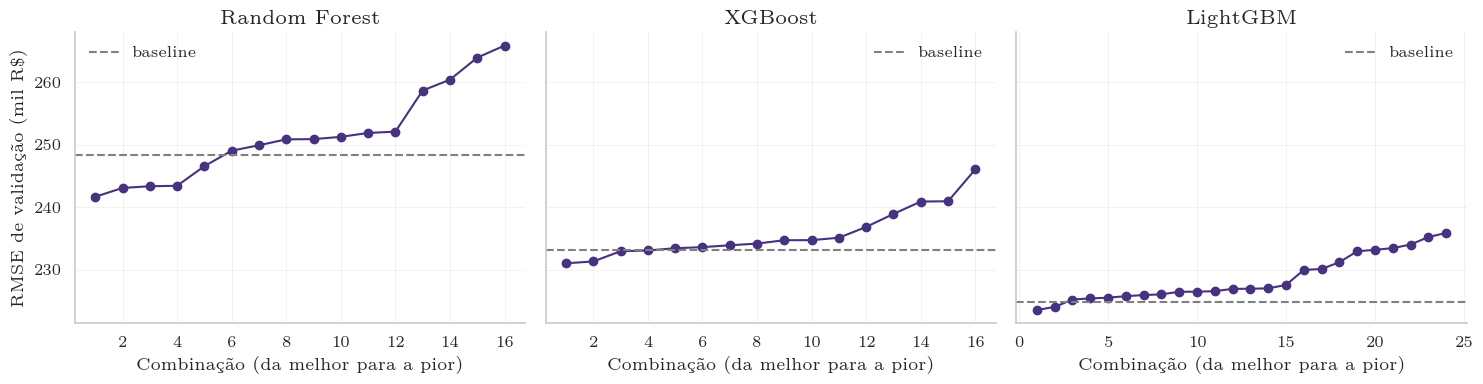

In [20]:
# RMSE de validação de todas as combinações testadas
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, (nome, busca) in enumerate(buscas_grid.items()):
    rmse = np.sort(-busca.cv_results_["mean_test_score"]) / 1000
    ax[i].plot(range(1, len(rmse) + 1), rmse, "o-")
    ax[i].axhline(baselines.set_index("Modelo").loc[nome, "RMSE_CV"] / 1000, ls="--", color="gray", label="baseline")
    ax[i].set_title(nome)
    ax[i].set_xlabel("Combinação (da melhor para a pior)")
    ax[i].legend()
ax[0].set_ylabel("RMSE de validação (mil R$)")
plt.tight_layout()
plt.show()

O Grid Search melhorou um pouco o Random Forest (de R$ 248,3 mil para R$ 241,7 mil) e o XGBoost (de R$ 233,2 mil para R$ 231,0 mil). No LightGBM a melhora foi pequena (de R$ 224,9 mil para R$ 223,6 mil). Em todos os casos o ganho foi menor que o desvio entre os folds, então os baselines já estavam perto do melhor que essas grades conseguem.

**Optuna.** Para cada modelo, a função objetivo recebe os hiperparâmetros sugeridos pelo Optuna, monta o mesmo pipeline e devolve o RMSE médio nos mesmos 5 folds. O Optuna usa o sampler TPE, que começa com tentativas aleatórias e depois usa os resultados anteriores para escolher as próximas. Fizemos 20 trials por modelo. Diferente da grade, os valores são sorteados dentro de intervalos, e incluímos a fração de linhas usada por árvore (`subsample`) nos modelos de boosting.

In [21]:
def rmse_cv(modelo):
    notas = cross_val_score(montar_pipeline(modelo), X_treino, y_treino, cv=cv,
                            scoring="neg_root_mean_squared_error")
    return -notas.mean()


def objetivo_rf(trial):
    return rmse_cv(RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 250, step=50),
        max_depth=trial.suggest_categorical("max_depth", [None, 10, 16, 24]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        random_state=SEED, n_jobs=-1))


def objetivo_xgb(trial):
    return rmse_cv(XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 1200, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 9),
        min_child_weight=trial.suggest_float("min_child_weight", 1, 15),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        random_state=SEED, n_jobs=-1))


def objetivo_lgbm(trial):
    return rmse_cv(LGBMRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 1200, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 8, 96),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 60),
        subsample=trial.suggest_float("subsample", 0.6, 1.0), subsample_freq=1,
        random_state=SEED, n_jobs=-1, verbose=-1))


estudos = {}
linhas = []
for nome, objetivo in [("Random Forest", objetivo_rf), ("XGBoost", objetivo_xgb), ("LightGBM", objetivo_lgbm)]:
    estudo = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    t0 = perf_counter()
    estudo.optimize(objetivo, n_trials=20)
    tempo = perf_counter() - t0
    estudos[nome] = estudo
    print(nome, "- melhores parâmetros:", {k: round(v, 4) if isinstance(v, float) else v for k, v in estudo.best_params.items()})
    linhas.append({"Modelo": nome, "Trials": 20, "RMSE_CV": estudo.best_value,
                   "Trial_do_melhor": estudo.best_trial.number + 1, "Tempo_s": tempo})

resultado_optuna = pd.DataFrame(linhas)
resultado_optuna.round(2)

Random Forest - melhores parâmetros: {'n_estimators': 150, 'max_depth': 24, 'min_samples_leaf': 1, 'max_features': 0.8081}


XGBoost - melhores parâmetros: {'n_estimators': 1100, 'learning_rate': 0.0331, 'max_depth': 5, 'min_child_weight': 14.4354, 'subsample': 0.632}


LightGBM - melhores parâmetros: {'n_estimators': 1200, 'learning_rate': 0.0191, 'num_leaves': 17, 'min_child_samples': 46, 'subsample': 0.8169}


,Modelo,Trials,RMSE_CV,Trial_do_melhor,Tempo_s
0,Random Forest,20,239398.90,19,276.86
1,XGBoost,20,224575.91,16,113.49
2,LightGBM,20,225261.57,20,93.71


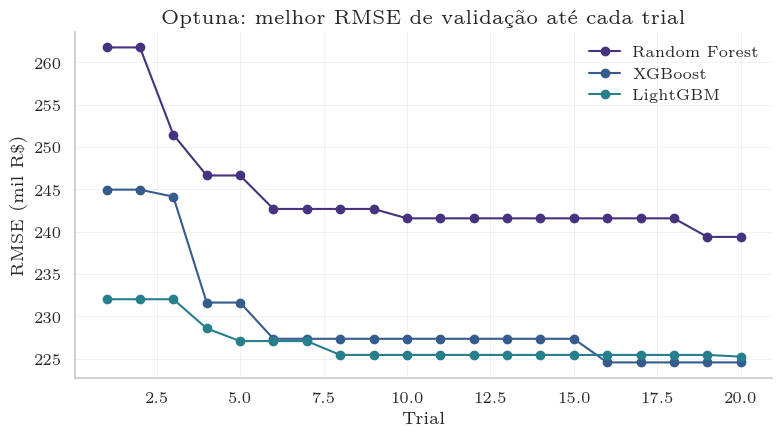

In [22]:
# melhor RMSE encontrado até cada trial
plt.figure(figsize=(9, 4.5))
for nome, estudo in estudos.items():
    valores = [t.value for t in estudo.trials]
    plt.plot(range(1, 21), np.minimum.accumulate(valores) / 1000, "o-", label=nome)
plt.title("Optuna: melhor RMSE de validação até cada trial")
plt.xlabel("Trial")
plt.ylabel("RMSE (mil R$)")
plt.legend()
plt.show()

In [23]:
# Grid Search x Optuna
comparacao = pd.DataFrame({
    "Modelo": resultado_grid["Modelo"],
    "RMSE_Grid": resultado_grid["RMSE_CV"],
    "RMSE_Optuna": resultado_optuna["RMSE_CV"],
    "Tempo_Grid_s": resultado_grid["Tempo_s"],
    "Tempo_Optuna_s": resultado_optuna["Tempo_s"],
    "Desvio_entre_folds": resultado_grid["RMSE_CV_dp"],
})
comparacao.round(2)

,Modelo,RMSE_Grid,RMSE_Optuna,Tempo_Grid_s,Tempo_Optuna_s,Desvio_entre_folds
0,Random Forest,241666.93,239398.90,185.13,276.86,28910.49
1,XGBoost,231022.26,224575.91,75.87,113.49,21472.14
2,LightGBM,223550.78,225261.57,137.81,93.71,23047.04


O Optuna chegou a resultados parecidos com os do Grid Search. No XGBoost ele foi melhor (R$ 224,6 mil contra R$ 231,0 mil), porque testou valores fora da grade, como `min_child_weight` perto de 14 e `subsample` de 0,63. No LightGBM ficou um pouco pior (R$ 225,3 mil contra R$ 223,6 mil), e no Random Forest foi um pouco melhor (R$ 239,4 mil contra R$ 241,7 mil). Todas essas diferenças são menores que o desvio entre os folds (entre R$ 21 mil e R$ 29 mil), então na prática as duas estratégias chegaram ao mesmo nível.

No tempo, o Optuna foi mais demorado no Random Forest e no XGBoost e mais rápido no LightGBM. Pelo gráfico, os melhores resultados apareceram perto do fim dos 20 trials, então com mais trials ele talvez ainda melhorasse um pouco.

<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.

**Resposta do aluno — Exercício 6**

Justifique a escolha do modelo final e interprete as evidências de overfitting, underfitting e importância das variáveis.

In [24]:
# tabela com as nove configurações (mesmos folds)
def modelo_com(nome, parametros):
    base = {"Random Forest": rf_base, "XGBoost": xgb_base, "LightGBM": lgbm_base}[nome]
    return base.__class__(**{**base.get_params(), **parametros})

configuracoes = {}
for nome in ["Random Forest", "XGBoost", "LightGBM"]:
    configuracoes[(nome, "Baseline")] = modelo_com(nome, {})
    configuracoes[(nome, "Grid Search")] = modelo_com(nome, {k.replace("regressor__modelo__", ""): v
                                                             for k, v in buscas_grid[nome].best_params_.items()})
    configuracoes[(nome, "Optuna")] = modelo_com(nome, estudos[nome].best_params)

linhas = []
for (nome, busca), modelo in configuracoes.items():
    linha = avaliar(nome, modelo)
    linha["Configuração"] = busca
    linhas.append(linha)

final = pd.DataFrame(linhas)
final["Gap_%"] = 100 * (final["RMSE_CV"] - final["RMSE_treino"]) / final["RMSE_treino"]
final = final[["Modelo", "Configuração", "RMSE_treino", "RMSE_CV", "RMSE_CV_dp", "Gap_%", "MAE_CV", "R2_CV", "Tempo_s"]]
final = final.sort_values("RMSE_CV").reset_index(drop=True)
final.round(2)

,Modelo,Configuração,RMSE_treino,RMSE_CV,RMSE_CV_dp,Gap_%,MAE_CV,R2_CV,Tempo_s
0,LightGBM,Grid Search,112691.47,223550.78,23047.04,98.37,96564.33,0.91,3.82
1,LightGBM,Baseline,106277.66,224897.62,22037.79,111.61,96960.32,0.91,4.38
2,LightGBM,Optuna,166274.75,225058.15,18354.12,35.35,97609.03,0.91,7.64
3,XGBoost,Optuna,130170.73,229738.38,20747.62,76.49,98474.91,0.90,5.80
4,XGBoost,Grid Search,87793.01,231022.26,21472.14,163.14,97605.04,0.90,4.53
5,XGBoost,Baseline,101998.39,233164.80,24843.35,128.60,98503.68,0.90,3.10
6,Random Forest,Optuna,94495.75,239398.90,29402.39,153.34,102957.20,0.89,17.98
7,Random Forest,Grid Search,95023.40,241666.93,28910.49,154.32,102684.49,0.89,23.63
8,Random Forest,Baseline,132543.88,248273.05,32248.09,87.31,105205.78,0.89,15.67


In [25]:
escolha = (final.loc[0, "Modelo"], final.loc[0, "Configuração"])
print("Configuração escolhida:", escolha)

Configuração escolhida: ('LightGBM', 'Grid Search')


O LightGBM do Grid Search teve o menor erro de validação (R$ 223,6 mil) e foi o escolhido. As três versões do LightGBM ficaram muito próximas (diferença de menos de R$ 1,5 mil), bem abaixo do desvio entre folds, então o LightGBM foi o melhor algoritmo nesta base, mas a versão exata faz pouca diferença.

Um ponto que consideramos: o LightGBM do Optuna tem o menor gap entre treino e validação (35%, contra 98% do escolhido), ou seja, ele decora menos o treino. Mesmo assim ficamos com o do Grid Search, porque ele erra um pouco menos na validação e treina em metade do tempo. O Random Forest ficou atrás em todas as versões.

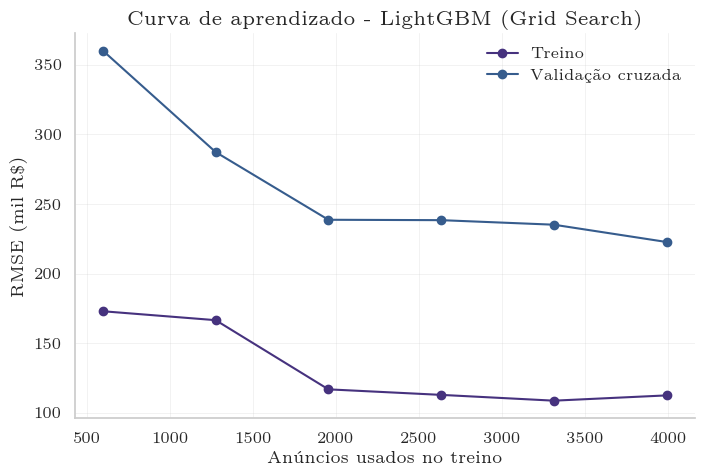

,Anúncios,RMSE_treino,RMSE_validacao
0,598,172924.0,360144.0
1,1277,166516.0,287288.0
2,1956,116815.0,238654.0
3,2635,112839.0,238371.0
4,3314,108677.0,235110.0
5,3993,112465.0,222681.0


In [26]:
# curva de aprendizado da configuração escolhida
tamanhos, treino, validacao = learning_curve(montar_pipeline(configuracoes[escolha]), X_treino, y_treino,
                                             cv=cv, train_sizes=np.linspace(0.15, 1.0, 6),
                                             scoring="neg_root_mean_squared_error")
plt.figure(figsize=(8, 5))
plt.plot(tamanhos, -treino.mean(axis=1) / 1000, "o-", label="Treino")
plt.plot(tamanhos, -validacao.mean(axis=1) / 1000, "o-", label="Validação cruzada")
plt.title(f"Curva de aprendizado - {escolha[0]} ({escolha[1]})")
plt.xlabel("Anúncios usados no treino")
plt.ylabel("RMSE (mil R$)")
plt.legend()
plt.show()

pd.DataFrame({"Anúncios": tamanhos, "RMSE_treino": -treino.mean(axis=1),
              "RMSE_validacao": -validacao.mean(axis=1)}).round(0)

Com poucos anúncios (cerca de 600) o erro de validação é alto, R$ 360 mil. Ele cai rápido até uns 2.000 anúncios e continua caindo devagar até R$ 223 mil com o treino completo. O erro de treino fica bem abaixo, em torno de R$ 110 mil.

A distância entre as duas curvas mostra que o modelo se ajusta ao treino melhor do que a dados novos (algum overfitting), mas essa distância vai diminuindo com mais dados. Como a curva de validação ainda está descendo, mais anúncios ajudariam o modelo.

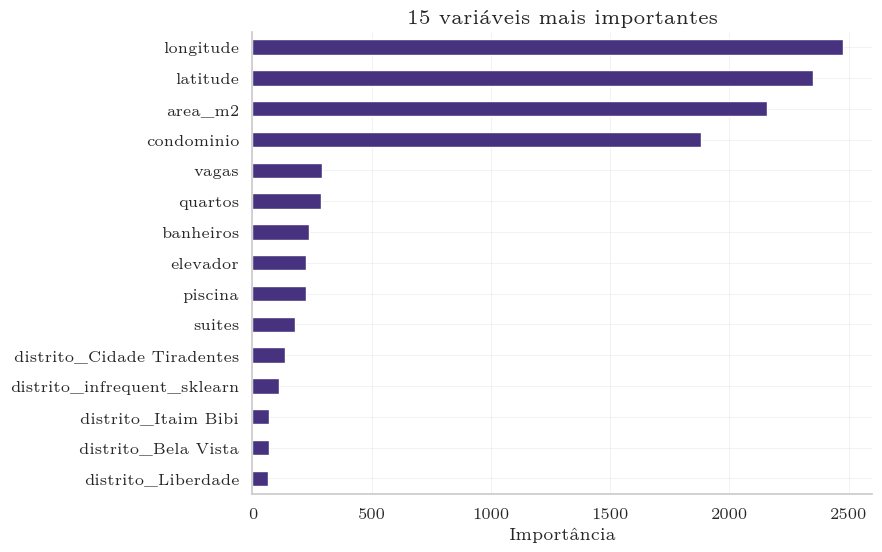

In [27]:
# importância das variáveis (modelo treinado no treino)
pipe = montar_pipeline(configuracoes[escolha]).fit(X_treino, y_treino)
nomes = pipe.regressor_.named_steps["preparo"].get_feature_names_out()
nomes = [n.replace("num__", "").replace("cat__", "") for n in nomes]
importancia = pd.Series(pipe.regressor_.named_steps["modelo"].feature_importances_, index=nomes)

importancia.sort_values().tail(15).plot(kind="barh", figsize=(8, 6))
plt.title("15 variáveis mais importantes")
plt.xlabel("Importância")
plt.show()

As variáveis mais usadas pelo modelo são longitude, latitude, área e condomínio, muito à frente das outras. Vagas, quartos e banheiros aparecem bem atrás, porque a informação delas já está em boa parte na área e no condomínio. Os distritos aparecem separados em várias colunas (por isso cada um tem importância pequena), e a localização acaba sendo representada principalmente pelas coordenadas.

Essa importância mostra quantas vezes o modelo usou a variável para dividir os dados, e não o quanto ela aumenta ou diminui o preço.

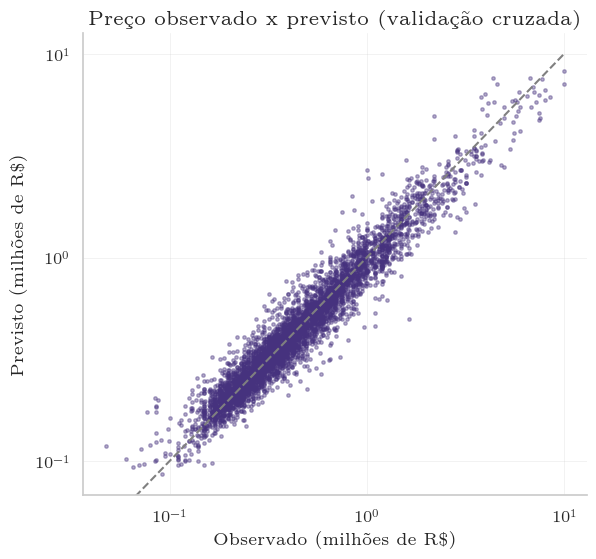

Erro percentual médio: 14.0 %
Metade dos imóveis tem erro abaixo de: 10.2 %


In [28]:
# previsto x observado, usando validação cruzada (o teste continua guardado)
previsto = cross_val_predict(montar_pipeline(configuracoes[escolha]), X_treino, y_treino, cv=cv)

plt.figure(figsize=(6.5, 6))
plt.scatter(y_treino / 1e6, previsto / 1e6, s=6, alpha=0.4)
plt.plot([0, 10], [0, 10], "--", color="gray")
plt.xscale("log")
plt.yscale("log")
plt.title("Preço observado x previsto (validação cruzada)")
plt.xlabel("Observado (milhões de R$)")
plt.ylabel("Previsto (milhões de R$)")
plt.show()

erro_pct = (100 * (y_treino - previsto).abs() / y_treino)
print("Erro percentual médio:", round(erro_pct.mean(), 1), "%")
print("Metade dos imóveis tem erro abaixo de:", round(erro_pct.median(), 1), "%")

Os pontos ficam em volta da linha de previsão perfeita em toda a faixa de preço, sem o modelo errar sempre para cima ou sempre para baixo. O erro médio é de 14% do valor do imóvel, e metade dos anúncios tem erro abaixo de 10%. Como treinamos com o log do preço, o erro fica parecido em porcentagem para imóveis baratos e caros.

<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>

**Resposta do aluno — Exercício 7**

Interprete o resultado do teste final, documente o teste de consistência, registre os links do GitHub e do Streamlit e prepare a síntese da solução para a apresentação oral de até 10 minutos.

In [29]:
modelo_final = montar_pipeline(configuracoes[escolha]).fit(X_treino, y_treino)
previsto_teste = modelo_final.predict(X_teste)

linha_cv = final.loc[0]
pd.DataFrame({
    "Validação cruzada": [linha_cv["RMSE_CV"], linha_cv["MAE_CV"], linha_cv["R2_CV"]],
    "Teste": [root_mean_squared_error(y_teste, previsto_teste), mean_absolute_error(y_teste, previsto_teste),
              r2_score(y_teste, previsto_teste)],
}, index=["RMSE", "MAE", "R²"]).round(3)

,Validação cruzada,Teste
RMSE,223550.780,191530.640
MAE,96564.333,87919.302
R²,0.909,0.938


No teste, o RMSE foi de R$ 191,5 mil, o MAE de R$ 87,9 mil e o R² de 0,94. O resultado ficou um pouco melhor que na validação cruzada (RMSE de R$ 223,6 mil), mas dentro da variação que vimos entre os folds (cerca de R$ 23 mil). Então o desempenho no teste é o que esperávamos, e o modelo generaliza bem para anúncios que ele não viu.

In [30]:
# teste de consistência com anúncios do teste
casos = X_teste.copy()
casos["preco_real"] = y_teste
casos["preco_previsto"] = previsto_teste.round(0)
casos["erro"] = casos["preco_real"] - casos["preco_previsto"]
casos["erro_%"] = (100 * casos["erro"] / casos["preco_real"]).round(1)

exemplos = pd.concat([
    casos.loc[[casos["erro_%"].abs().idxmin()]],                     # melhor acerto
    casos.loc[[casos["erro_%"].abs().idxmax()]],                     # caso mais difícil
    casos.drop(index=[casos["erro_%"].abs().idxmin(), casos["erro_%"].abs().idxmax()]).sample(4, random_state=SEED),
])
exemplos[["distrito", "area_m2", "quartos", "banheiros", "vagas", "condominio", "preco_real", "preco_previsto", "erro", "erro_%"]]

,distrito,area_m2,quartos,banheiros,vagas,condominio,preco_real,preco_previsto,erro,erro_%
2778,São Domingos,47,2,2,1,570.0,299000,298894.0,106.0,0.0
1894,Ipiranga,110,3,2,2,1500.0,450000,927473.0,-477473.0,-106.1
1902,Ipiranga,72,3,2,1,550.0,550000,520285.0,29715.0,5.4
1832,Cursino,49,2,2,1,404.0,219000,233802.0,-14802.0,-6.8
947,Carrão,60,2,2,1,NaN,385000,366697.0,18303.0,4.8
4894,Jaçanã,67,3,2,1,300.0,315000,330081.0,-15081.0,-4.8


O melhor acerto foi um apartamento de 47 m² em São Domingos: R$ 299.000 anunciado e R$ 298.894 previsto. Nos quatro anúncios sorteados o erro ficou entre 4,8% e 6,8%.

O caso mais difícil é um apartamento de 110 m² no Ipiranga, com 3 quartos, 2 vagas e condomínio de R$ 1.500, anunciado por R$ 450 mil. O modelo previu R$ 927 mil. Pelas características, principalmente o condomínio alto, o preço anunciado parece baixo; pode ser erro no anúncio ou algo que a base não mostra, como o estado do imóvel. O modelo seguiu o padrão que aprendeu, e esse caso mostra o limite de prever só com as informações do anúncio.

In [31]:
# salva o modelo e as informações que o app precisa
os.makedirs("modelo", exist_ok=True)
joblib.dump(modelo_final, "modelo/modelo_final.joblib")

exemplo_paridade = exemplos.iloc[2]
entrada = {c: (None if pd.isna(exemplo_paridade[c]) else exemplo_paridade[c]) for c in colunas_x}
entrada = {k: (v.item() if hasattr(v, "item") else v) for k, v in entrada.items()}
info = {
    "modelo": f"{escolha[0]} ({escolha[1]})",
    "rmse_teste": root_mean_squared_error(y_teste, previsto_teste),
    "mae_teste": mean_absolute_error(y_teste, previsto_teste),
    "r2_teste": r2_score(y_teste, previsto_teste),
    "distritos": sorted(X_treino["distrito"].unique().tolist()),
    "faixas": {c: [float(X_treino[c].min()), float(X_treino[c].max())] for c in ["area_m2", "quartos", "banheiros", "vagas", "condominio"]},
    "paridade_entrada": entrada,
    "paridade_previsao_notebook": float(modelo_final.predict(pd.DataFrame([entrada]).astype({c: "float" for c in colunas_numericas}))[0]),
}
with open("modelo/info.json", "w", encoding="utf-8") as f:
    json.dump(info, f, ensure_ascii=False, indent=2)
venda.to_csv("base_tratada.csv", index=False)

print("Anúncio usado no teste de paridade:", entrada)
print("Previsão do notebook: R$", round(info["paridade_previsao_notebook"], 2))

Anúncio usado no teste de paridade: {'area_m2': 72, 'quartos': 3, 'banheiros': 2, 'suites': 1, 'vagas': 1, 'condominio': 550.0, 'elevador': 1, 'mobiliado': 0, 'piscina': 1, 'novo': 0, 'latitude': -23.596728, 'longitude': -46.604326, 'distrito': 'Ipiranga'}
Previsão do notebook: R$ 520285.28


No app, o botão "Usar o anúncio do teste de paridade" preenche o formulário com esse mesmo anúncio. A previsão mostrada deve ser igual à do notebook, porque o app carrega o mesmo arquivo `modelo_final.joblib` e usa a mesma função `limpar_imovel`.

### Síntese da solução para a apresentação

**Problema, base e alvo.** Prever o preço de venda anunciado de apartamentos em São Paulo (regressão), com a mesma base do CP04: anúncios de abril de 2019, 6.240 depois do tratamento.

**Data wrangling e variáveis.** Além das duplicatas, encontramos problemas que não tínhamos visto no CP04: condomínio e coordenadas zerados (tratados como informação faltando), o "distrito" Medeiros com coordenadas em Jundiaí, anúncios com mais suítes que quartos e 10 preços incoerentes para o distrito. Usamos 13 variáveis; o preço por m² ficou de fora por vazamento. Imputação e codificação ficam dentro do pipeline, e o modelo aprende o log do preço porque ele é muito assimétrico.

**Comparação dos modelos.** Nos baselines, o LightGBM teve o menor erro (R\$ 224,9 mil), seguido do XGBoost (R\$ 233,2 mil) e do Random Forest (R\$ 248,3 mil).

**Grid Search e Optuna.** As duas buscas chegaram ao mesmo nível de erro, com diferenças menores que a variação entre os folds. O modelo final é o LightGBM do Grid Search, que teve o menor erro de validação (R\$ 223,6 mil) e treina rápido.

**Overfitting e underfitting.** O erro de treino é cerca de metade do erro de validação, então há algum overfitting, mas a curva de aprendizado mostra essa distância diminuindo com mais dados. Não há underfitting (R² de validação de 0,91).

**Teste final.** RMSE de R\$ 191,5 mil, MAE de R\$ 87,9 mil e R² de 0,94, dentro da variação esperada pela validação cruzada. O erro médio fica em torno de 14% do valor do imóvel.

**Streamlit e paridade.** O app carrega o mesmo `modelo_final.joblib` e usa a mesma função `limpar_imovel`. O anúncio de paridade (72 m² no Ipiranga) dá R\$ 520.285,28 no notebook e deve dar o mesmo valor no app.

**Roteiro sugerido (10 minutos)**

| Tempo | Parte |
|---|---|
| 1 min | Problema, base e o que mudou desde o CP04 |
| 2 min | Data wrangling: problemas encontrados e decisões |
| 1 min | Variáveis, vazamento e protocolo (treino/teste, 5 folds, RMSE) |
| 2 min | Baselines, Grid Search, Optuna e escolha do modelo |
| 1,5 min | Overfitting (curva de aprendizado) e importância das variáveis |
| 1 min | Teste final e teste de consistência |
| 1,5 min | Demonstração do Streamlit e teste de paridade |

In [32]:
URL_GITHUB = ""
URL_STREAMLIT = ""

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

GitHub: 
Streamlit: 


<br>

---

<br>

# **Referências**

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.

<br>

---

<br>

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).